# purpose
to plot data from SF for Rob 

# imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, math, sys

In [2]:
# user inputs
df = pd.read_csv('/Users/dennise/Downloads/2024_tubetests - Sheet1.csv')

In [3]:
df=df[df.good==1]

In [4]:
df['notclose']=1-df.close

In [5]:
df['winner_notclose']=df.winner*df.notclose

In [7]:
df

,good,date,cage,animalA,animalB,winner,close,notclose,winner_notclose
0,1,20240615,1,219,217,217,0,1,217
1,1,20240615,1,217,213,213,0,1,213
2,1,20240615,1,213,215,215,0,1,215
3,1,20240615,1,213,217,213,0,1,213
4,1,20240615,1,213,219,213,0,1,213
...,...,...,...,...,...,...,...,...,...
254,1,20240806,2,1,4,1,0,1,1
255,1,20240806,2,2,11,0,0,1,0
256,1,20240806,1,215,32,0,0,1,0
257,1,20240806,2,1,13,0,0,1,0


In [13]:
df2=df[df.cage==2]
df2=df2[df2.animalB<12]
df2

,good,date,cage,animalA,animalB,winner,close,notclose,winner_notclose
86,1,20240615,2,1,2,1,0,1,1
87,1,20240615,2,1,3,1,0,1,1
88,1,20240615,2,1,4,1,0,1,1
89,1,20240615,2,1,11,0,0,1,0
90,1,20240615,2,2,3,2,0,1,2
91,1,20240615,2,2,4,2,0,1,2
92,1,20240615,2,2,11,0,0,1,0
93,1,20240615,2,3,4,4,0,1,4
94,1,20240615,2,3,11,3,0,1,3
95,1,20240615,2,4,11,11,0,1,11


In [18]:
df2_pre = df2[df2.date<20240806]
df2_pre

,good,date,cage,animalA,animalB,winner,close,notclose,winner_notclose
86,1,20240615,2,1,2,1,0,1,1
87,1,20240615,2,1,3,1,0,1,1
88,1,20240615,2,1,4,1,0,1,1
89,1,20240615,2,1,11,0,0,1,0
90,1,20240615,2,2,3,2,0,1,2
91,1,20240615,2,2,4,2,0,1,2
92,1,20240615,2,2,11,0,0,1,0
93,1,20240615,2,3,4,4,0,1,4
94,1,20240615,2,3,11,3,0,1,3
95,1,20240615,2,4,11,11,0,1,11


In [ ]:
#list(df2_pre.winner_notclose[(df2_pre.animalA==1)&(df2_pre.animalB==2)])

[1]

In [82]:
allanimals=[list(df2_pre.animalA.astype(str)) + list(df2_pre.animalB.astype(str))]
wins=pd.DataFrame(columns=[['animalB'] + list(np.unique(allanimals))])
wins['animalB']=np.unique(allanimals)
wins

,animalB,1,11,2,3,4
0,1,NaN,NaN,NaN,NaN,NaN
1,11,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN
4,4,NaN,NaN,NaN,NaN,NaN


In [163]:
alltests=[]
for anmA in np.unique(allanimals):
    winsvals=[]
    lossesvals=[]
    totaltests=0
    print('anmA is {}'.format(anmA))
    for anmB in np.unique(allanimals):
        if anmA==anmB:
            winsvals.append(np.nan)
            lossesvals.append(np.nan)
        else:
            listofvalsA=list(df2_pre.winner_notclose[(df2_pre.animalA==int(anmA))&(df2_pre.animalB==int(anmB))])
            listofvalsB=list(df2_pre.winner_notclose[(df2_pre.animalA==int(anmB))&(df2_pre.animalB==int(anmA))])
            listofvals=listofvalsA+listofvalsB
            totaltests=totaltests+len(listofvals)
            print(anmA,anmB,totaltests)
            # get number of wins
            winsvals.append(len([val for val in listofvals if val==int(anmA)]))
            lossesvals.append(len([val for val in listofvals if val==int(anmB)]))
    wins[str(anmA)]=lossesvals
    alltests.append(totaltests)
print(alltests)
wins['numtests']=alltests
wins


anmA is 1
1 11 1
1 2 2
1 3 3
1 4 4
anmA is 11
11 1 1
11 2 2
11 3 3
11 4 4
anmA is 2
2 1 1
2 11 2
2 3 3
2 4 4
anmA is 3
3 1 1
3 11 2
3 2 3
3 4 4
anmA is 4
4 1 1
4 11 2
4 2 3
4 3 4
[4, 4, 4, 4, 4]


,animalB,1,11,2,3,4,numtests
0,1,NaN,0.0,1.0,1.0,1.0,4
1,11,0.0,NaN,0.0,0.0,1.0,4
2,2,0.0,0.0,NaN,1.0,1.0,4
3,3,0.0,1.0,0.0,NaN,0.0,4
4,4,0.0,0.0,0.0,1.0,NaN,4


In [164]:
#get proportion of wins
Pwins = pd.DataFrame(columns=[['animalB']+[str(val) for val in np.unique(allanimals)]])
Pwins['animalB']=wins.animalB
for anm in Pwins.columns[1:]:
    for i in wins.index:
        Pwins[anm]=wins[anm]/int(wins.numtests.iloc[i])

C:\Users\dennise\AppData\Local\Temp\ipykernel_30292\4151742895.py:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  Pwins[anm]=wins[anm]/int(wins.numtests.iloc[i])


In [165]:
#get ws
anmcoldf=Pwins[[str(val) for val in list(np.unique(allanimals))]]
Pwins['w']=anmcoldf.sum(axis=1)
Pwins

,animalB,1,11,2,3,4,w
0,1,NaN,0.00,0.25,0.25,0.25,0.75
1,11,0.0,NaN,0.00,0.00,0.25,0.25
2,2,0.0,0.00,NaN,0.25,0.25,0.50
3,3,0.0,0.25,0.00,NaN,0.00,0.25
4,4,0.0,0.00,0.00,0.25,NaN,0.25


In [166]:
#make it a matrix
matrixvals=anmcoldf.to_numpy()
wvals=Pwins.w.to_numpy().transpose()
forw2calc=pd.DataFrame(matrixvals * wvals,columns=anmcoldf.columns)
Pwins['w2']=forw2calc.sum(axis=1)
Pwins

,animalB,1,11,2,3,4,w,w2
0,1,NaN,0.00,0.25,0.25,0.25,0.75,0.2500
1,11,0.0,NaN,0.00,0.00,0.25,0.25,0.0625
2,2,0.0,0.00,NaN,0.25,0.25,0.50,0.1250
3,3,0.0,0.25,0.00,NaN,0.00,0.25,0.0625
4,4,0.0,0.00,0.00,0.25,NaN,0.25,0.0625


In [167]:
ls=anmcoldf.sum(axis=0).to_numpy().transpose()
ls

array([0.  , 0.25, 0.25, 0.75, 0.75])

In [168]:
# get ls, l2s
forl2calc = pd.DataFrame(matrixvals*ls,columns=anmcoldf.columns)
l2s=forl2calc.sum(axis=0).to_numpy().transpose()
Pwins.loc[len(Pwins)]=['l']+list(ls)+[np.nan,np.nan]
Pwins.loc[len(Pwins)]=['l2']+list(l2s)+[np.nan,np.nan]
Pwins

,animalB,1,11,2,3,4,w,w2
0,1,NaN,0.0000,0.2500,0.2500,0.2500,0.75,0.2500
1,11,0.0,NaN,0.0000,0.0000,0.2500,0.25,0.0625
2,2,0.0,0.0000,NaN,0.2500,0.2500,0.50,0.1250
3,3,0.0,0.2500,0.0000,NaN,0.0000,0.25,0.0625
4,4,0.0,0.0000,0.0000,0.2500,NaN,0.25,0.0625
5,l,0.0,0.2500,0.2500,0.7500,0.7500,NaN,NaN
6,l2,0.0,0.0625,0.0625,0.5625,0.5625,NaN,NaN


In [ ]:
# now want DS for each animal which is 
# w + w2 - l -l2


# and normDS which is
# normDS = [DS + N(N-1)/2]/N


In [10]:
wins_before=[]
wins_after=[]
winsnotclose_before=[]
winsnotclose_after=[]
df_before = df[df.date < 20240800]
df_after=df[df.date>20240800]
cage=[]
for anm in animals:
    cageval=np.median(df_before.cage[df_before.animalA==anm])
    if np.isnan(cageval):
        cage.append(np.median(df_before.cage[df_before.animalB==anm]))
    else:
        cage.append(np.median(df_before.cage[df_before.animalA==anm]))
    wins_before.append(len(df_before[df_before.winner==anm]))
    winsnotclose_before.append(len(df_before[df_before.winner_notclose==anm]))
    wins_after.append(len(df_after[df_after.winner==anm]))
    winsnotclose_after.append(len(df_after[df_after.winner_notclose==anm]))

C:\Users\dennise\AppData\Local\miniforge3\envs\fieldwork\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\dennise\AppData\Local\miniforge3\envs\fieldwork\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [12]:
new_df=pd.DataFrame(columns=['cage','anm','wins_before','wins_notclose_before','wins_after','wins_notclose_after'])
new_df.cage=cage
new_df.anm=animals
new_df.wins_before = wins_before
new_df.wins_notclose_before = winsnotclose_before
new_df.wins_after = wins_after
new_df.wins_notclose_after = winsnotclose_after

In [13]:
new_df

,cage,anm,wins_before,wins_notclose_before,wins_after,wins_notclose_after
0,2.0,1,4,3,4,1
1,2.0,2,3,3,1,0
2,2.0,3,2,2,1,1
3,2.0,4,2,1,1,1
4,2.0,11,4,2,1,1
5,3.0,12,1,1,0,0
6,3.0,13,4,1,2,2
7,3.0,14,2,1,1,1
8,3.0,21,1,1,2,2
9,3.0,22,1,1,1,1


In [38]:
dftoplot = pd.read_csv('/Users/dennise/Desktop/2024_cageonly.csv')

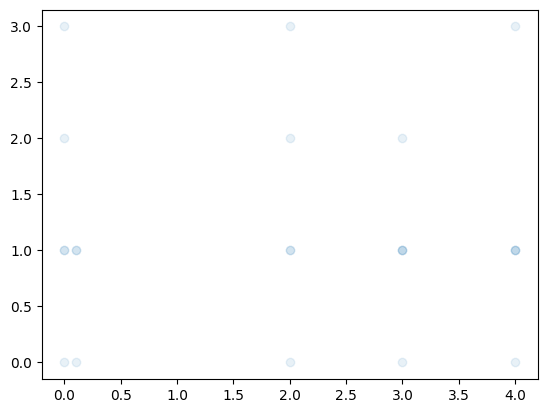

In [39]:
plt.scatter(dftoplot.cage,abs(dftoplot.wins_after-dftoplot.wins_before),alpha=0.1)

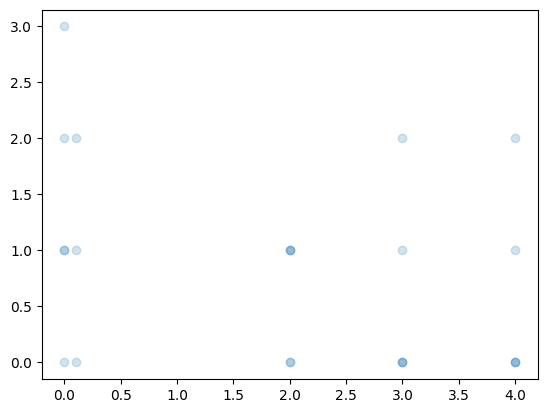

In [40]:
plt.scatter(dftoplot.cage,dftoplot.abs_wins,alpha=0.2)

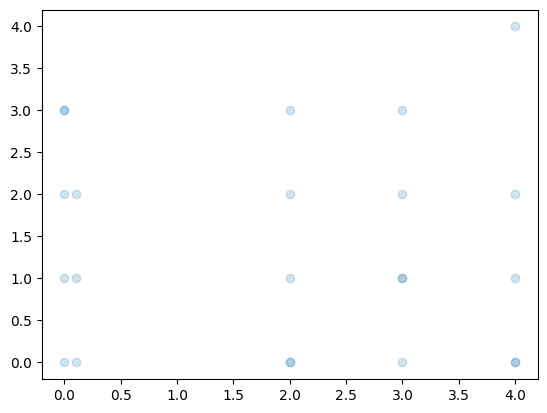

In [41]:
plt.scatter(dftoplot.cage,dftoplot.abs_pessimist_wins,alpha=0.2)

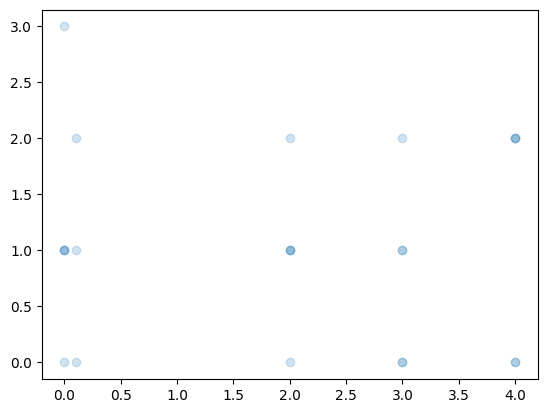

In [42]:
plt.scatter(dftoplot.cage,dftoplot.abs_notclose_wins,alpha=0.2)

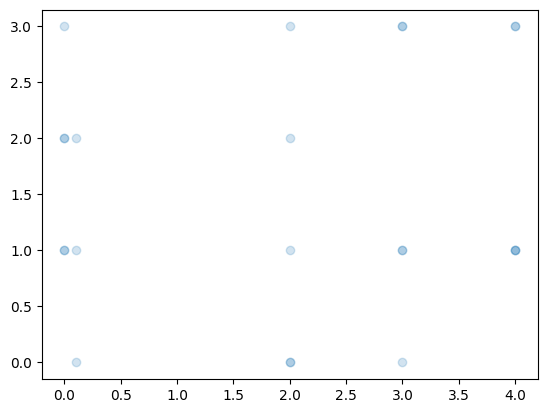

In [43]:
plt.scatter(dftoplot.cage,dftoplot.abs_notclose_pessimist,alpha=0.2)

In [44]:
group=[]
for val in dftoplot.cage:
    if val>0.1:
        group.append(1)
    else:
        group.append(0)

In [45]:
dftoplot['group']=group

Text(0.5, 1.0, 'rank_change_by_wins')

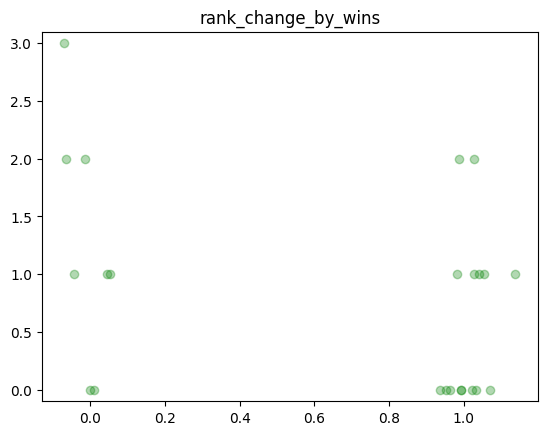

In [46]:
x_jittered = dftoplot.group + np.random.normal(0, 0.05, len(dftoplot))
plt.scatter(x_jittered, dftoplot.abs_wins,alpha=0.3,c='g')
plt.ylim(-.1,3.1)
plt.title('rank_change_by_wins')

Text(0.5, 1.0, 'rank_change_by_tie-to-low_wins')

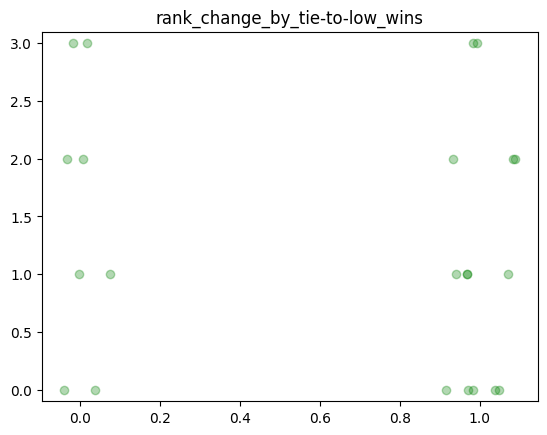

In [50]:
x_jittered = dftoplot.group + np.random.normal(0, 0.05, len(dftoplot))
plt.scatter(x_jittered, dftoplot.abs_pessimist_wins,alpha=0.3,c='g')
plt.ylim(-.1,3.1)
plt.title('rank_change_by_tie-to-low_wins')

Text(0.5, 1.0, 'rank_change_by_not-close_wins')

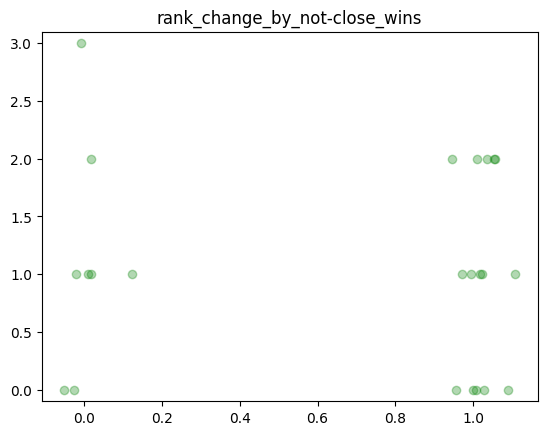

In [52]:
x_jittered = dftoplot.group + np.random.normal(0, 0.05, len(dftoplot))
plt.scatter(x_jittered, dftoplot.abs_notclose_wins,alpha=0.3,c='g')
plt.ylim(-.1,3.1)
plt.title('rank_change_by_not-close_wins')

Text(0.5, 1.0, 'rank_change clean wins, pessimist ranking')

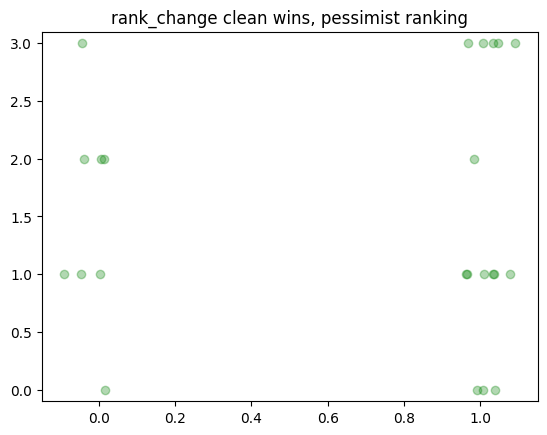

In [55]:
x_jittered = dftoplot.group + np.random.normal(0, 0.05, len(dftoplot))
plt.scatter(x_jittered, dftoplot.abs_notclose_pessimist,alpha=0.3,c='g')
plt.ylim(-.1,3.1)
plt.title('rank_change clean wins, pessimist ranking')


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


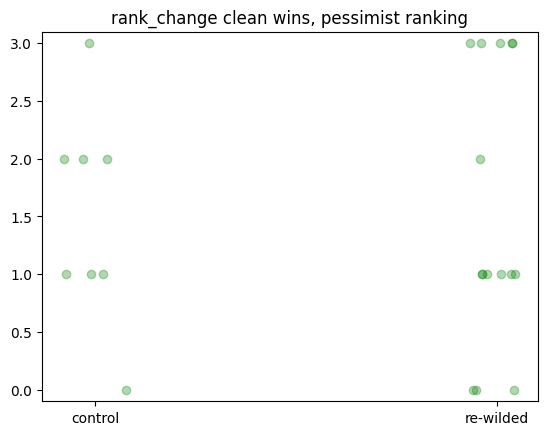

In [60]:
x_jittered = dftoplot.group + np.random.normal(0, 0.05, len(dftoplot))
plt.scatter(x_jittered, dftoplot.abs_notclose_pessimist,alpha=0.3,c='g')
plt.ylim(-.1,3.1)
plt.title('rank_change clean wins, pessimist ranking')
plt.xticks([0,1],labels=['control','re-wilded'])
plt.savefig('/Users/dennise/Desktop/forRob.eps')

(-0.1, 1.0)

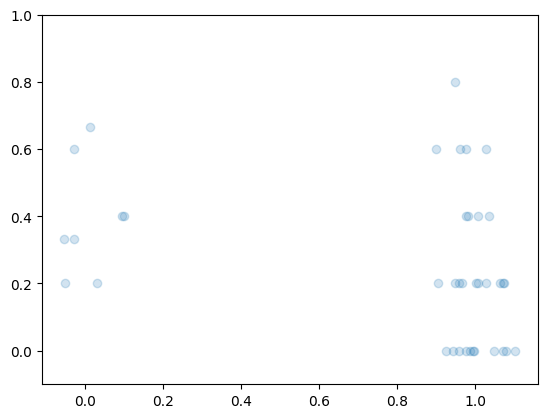

In [29]:
x_jittered = df.group + np.random.normal(0, 0.05, len(df))
plt.scatter(x_jittered, df.abs_rank_norm_extr,alpha=0.2)
plt.ylim(-.1,1)
